In [1]:
import os
import json

import numpy as np
# import pandas as pd
import scipy.ndimage as ndi

from scipy.ndimage import binary_closing, binary_dilation
from skimage.morphology import ball

from utils import (
    get_vesselness,
    load_vesselness_cache,
    save_vesselness_cache,
    # get_vesselness_optimized,
    plot_mip_projection,
    visualize_aorta_with_ostia,
    run_core_preprocessing_pipeline,
    find_ostia,
    region_growing_segmentation,
    load_raw_img_and_label,
    dice_score,
    check_ostium_intersection,
    visualize_3d_k3d,
    # region_growing_article,
    downscale_image_ndi,
    detect_aorta_circles,
    level_set_segmentation,
    remove_leaks_morphology,
    keep_largest_component,
)

# Segmentar Artéria via Crescimento de Região

## Carregar dados

In [ ]:
# ============================================================================
# CONFIGURAÇÕES
# ============================================================================
LOAD_CACHE = False
SAVE_CACHE = False

# Parâmetros de entrada
IMG_ID = 640  # [1, 2, 3, 4, 134, 195, 401, 487, 491, 548, 649]

# Caminhos
base_path = '/data04/home/mpmaia/ImageCAS/database/1-1000'
base_save_path = '/media/matheus/HD/DatasetsCCTA/Processed_ImageCAS'

# ============================================================================
# CARREGAR DADOS
# ============================================================================
nii_img, nii_label = load_raw_img_and_label(
    f'{base_path}/{IMG_ID}.img.nii.gz',
    f'{base_path}/{IMG_ID}.label.nii.gz'
)

spacing = nii_img.header.get_zooms()  # (dx, dy, dz)
img = np.array(nii_img.get_fdata())
label = np.array(nii_label.get_fdata()).astype(np.uint8)

# ============================================================================
# PRÉ-PROCESSAMENTO
# ============================================================================
downscale_factors = (2, 2, 1)  # Fatores de escala

down_image, thresh_image, lcc_image, thresh_vals = run_core_preprocessing_pipeline(
    img,
    downscale_factors=downscale_factors,
    lcc_per_slice=True
)

label = downscale_image_ndi(label, downscale_factors, order=0)

# Calcular novo espaçamento após downscale
dx = spacing[0] * downscale_factors[0]
dy = spacing[1] * downscale_factors[1]
dz = spacing[2] * downscale_factors[2]

# Calcular range de intensidade
vmin, vmax = lcc_image.min(), lcc_image.max()

# Calcular matriz afim ajustada para downscale
affine_downscaled = nii_img.affine.copy()
affine_downscaled[0, 0] /= downscale_factors[0]
affine_downscaled[1, 1] /= downscale_factors[1]
affine_downscaled[2, 2] /= downscale_factors[2]

# Imprimir informações
print("=" * 70)
print("INFORMAÇÕES DA IMAGEM")
print("=" * 70)
print(f"ID da imagem:         {IMG_ID}")
print(f"Espaçamento original: {spacing}")
print(f"Espaçamento ajustado: ({dx:.4f}, {dy:.4f}, {dz:.4f})")
print(f"Shape da imagem:      {lcc_image.shape}")
print(f"Range de intensidade: [{lcc_image.min()}, {lcc_image.max()}]")
print("=" * 70 + "\n")

IMG_ID: 640
Spacing: (np.float32(0.36132812), np.float32(0.36132812), np.float32(0.5))
Shape da imagem: (256, 256, 275)
Min e Max da imagem: -300.0, 521.9984778669717



## Localizar e Segmentar Aorta

In [ ]:
# ============================================================================
# CONFIGURAÇÕES DE SEGMENTAÇÃO DA AORTA
# ============================================================================

# Parâmetros de detecção de círculos (Transformada de Hough)
CIRCLE_DETECTION_CONFIG = {
    'radii_start_mm': 36,
    'radii_end_mm': 62,
    'tol_radius_mm': 9.0,
    'tol_distance_mm': 18.0,
    'max_slice_miss_threshold': 5,
    'neighbor_distance_threshold': 5,
    'total_num_peaks_initial': 10,
    'total_num_peaks': 15,
    'canny_sigma': 3,
}

# Parâmetros de segmentação com Level Set
LEVEL_SET_CONFIG = {
    'radius_reduction_factor': 0.15,
    'num_iter': 31,
    'balloon': 0.8,
    'smoothing': 2,
}

# Parâmetros de pós-processamento
POSTPROCESS_CONFIG = {
    'remove_leaks_radius': 2,
}

# ============================================================================
# CARREGAR OU SEGMENTAR MÁSCARA DA AORTA
# ============================================================================

saved_dir_aorta = f"{base_save_path}/segmented_aorta"
mask_path = os.path.join(saved_dir_aorta, f"{IMG_ID}_mask_aorta.npy")

if LOAD_CACHE and os.path.exists(mask_path):
    # Carregar máscara pré-computada
    aorta_mask = np.load(mask_path).astype(np.uint8)
    print("=" * 70)
    print("SEGMENTAÇÃO DA AORTA - CARREGADA DO CACHE")
    print("=" * 70)
    print(f"✓ Máscara carregada: {aorta_mask.shape}")
    print(f"Valores únicos:      {np.unique(aorta_mask)}")
    print(f"Voxels de aorta:     {np.sum(aorta_mask):,}")
    print("=" * 70 + "\n")

else:
    print("=" * 70)
    print("SEGMENTAÇÃO DA AORTA - CALCULADA")
    print("=" * 70)

    # -------- Detecção de círculos (Transformada de Hough) --------
    print("\n1. Detectando círculos da aorta...")

    radii_start = CIRCLE_DETECTION_CONFIG['radii_start_mm'] / downscale_factors[0]
    radii_end = CIRCLE_DETECTION_CONFIG['radii_end_mm'] / downscale_factors[0]
    hough_radii = np.arange(radii_start, radii_end, 1)
    pixel_spacing = (dx + dy) / 2.0

    detected_circles = detect_aorta_circles(
        lcc_image,
        hough_radii,
        pixel_spacing,
        tol_radius_mm=CIRCLE_DETECTION_CONFIG['tol_radius_mm'],
        tol_distance_mm=CIRCLE_DETECTION_CONFIG['tol_distance_mm'],
        max_slice_miss_threshold=CIRCLE_DETECTION_CONFIG['max_slice_miss_threshold'],
        neighbor_distance_threshold=CIRCLE_DETECTION_CONFIG['neighbor_distance_threshold'],
        total_num_peaks_initial=CIRCLE_DETECTION_CONFIG['total_num_peaks_initial'],
        total_num_peaks=CIRCLE_DETECTION_CONFIG['total_num_peaks'],
        canny_sigma=CIRCLE_DETECTION_CONFIG['canny_sigma'],
    )

    print(f"   ✓ {len(detected_circles)} círculos detectados")

    # -------- Segmentação com Level Set --------
    print("\n2. Segmentando com Level Set...")

    mask_refined = level_set_segmentation(
        lcc_image,
        detected_circles,
        radius_reduction_factor=LEVEL_SET_CONFIG['radius_reduction_factor'],
        num_iter=LEVEL_SET_CONFIG['num_iter'],
        balloon=LEVEL_SET_CONFIG['balloon'],
        smoothing=LEVEL_SET_CONFIG['smoothing'],
    )

    print("   ✓ Level Set concluído")

    # -------- Pós-processamento --------
    print("\n3. Pós-processamento...")

    aorta_mask = remove_leaks_morphology(
        mask_refined,
        radius=POSTPROCESS_CONFIG['remove_leaks_radius']
    )
    aorta_mask = keep_largest_component(aorta_mask)
    aorta_mask = aorta_mask.astype(np.uint8)

    print(f"   ✓ Aorta segmentada: {aorta_mask.shape}")
    print(f"     Voxels: {np.sum(aorta_mask):,}")

    # -------- Salvar máscara --------
    if SAVE_CACHE:
        os.makedirs(saved_dir_aorta, exist_ok=True)
        np.save(mask_path, aorta_mask)
        print(f"\n✓ Máscara salva em: {mask_path}")
    else:
        print("\n⊘ Máscara não foi salva (SAVE_CACHE=False)")

    print("=" * 70 + "\n")

Detectando círculos da aorta...
Parada na fatia 147: Δr=1.00 ou dist=39.65
✓ 127 círculos detectados
Segmentando aorta com Level Set...
✓ Aorta segmentada: (256, 256, 275)
Voxels de aorta: 249,015

✓ Máscara salva em: /media/matheus/HD/DatasetsCCTA/Processed_ImageCAS/segmented_aorta/640_mask_aorta.npy



## Mapa de Vesselness

✓ Vesselness calculado e salvo no cache!
Shape Vesselness: (256, 256, 275)
Vesselness min: 0.0, max: 0.7021842901303059
Mean: 0.0016391915985614893, std: 0.01156719357928782


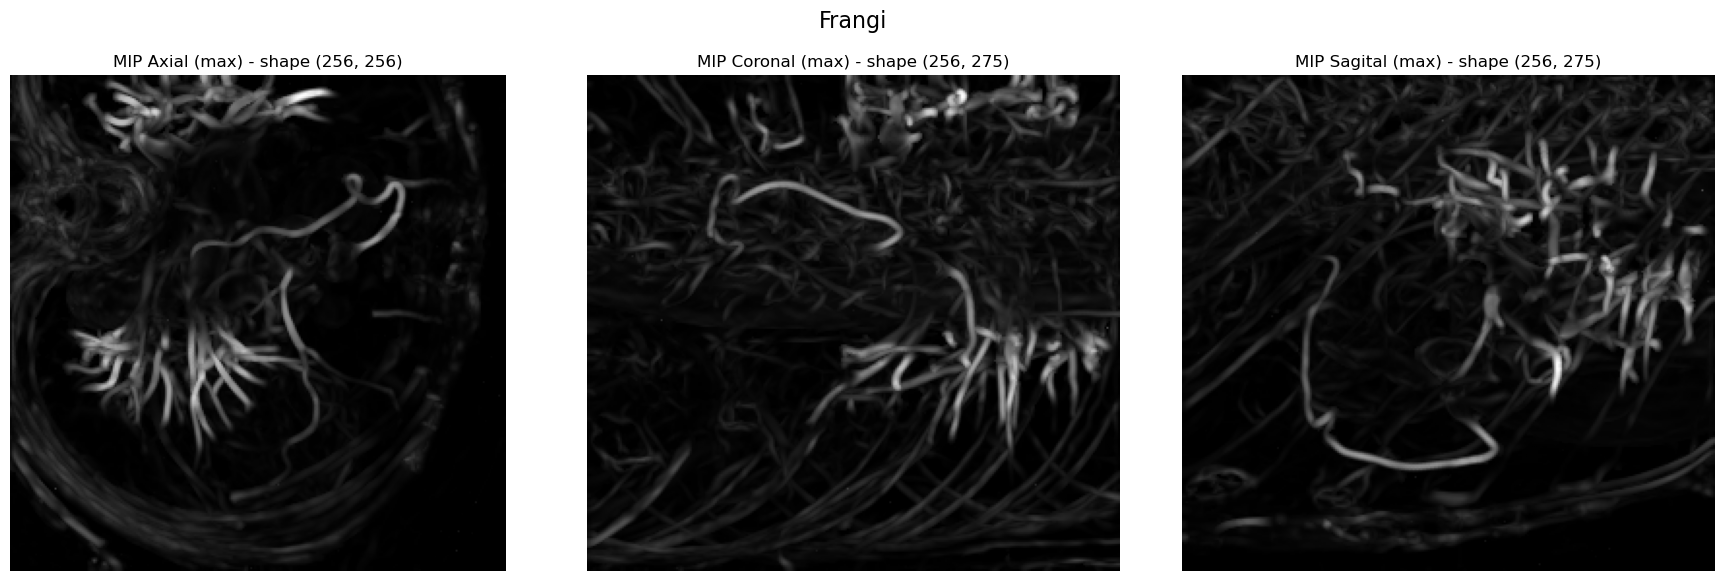

In [ ]:
# ============================================================================
# CONFIGURAÇÕES - VESSELNESS PARA DETECÇÃO DE ÓSTIOS
# ============================================================================

VESSELNESS_OSTIA_CONFIG = {
    'sigmas': np.arange(2.5, 3.5, 1),
    'black_ridges': False,
    'alpha': 0.5,      # Distinção: Tubular (artéria) vs Plana
    'beta': 1,         # Distinção: Tubo (comprido) vs Bola (blob)
    'gamma': 30,       # Sensibilidade ao Contraste/Intensidade
    'normalization': 'none',
}

# ============================================================================
# CALCULAR MAPA DE VESSELNESS PARA ÓSTIOS
# ============================================================================

vesselness_cache_dir = f'{base_save_path}/vesselness_cache'
vesselness_i = None

cache = load_vesselness_cache(IMG_ID, cache_dir=vesselness_cache_dir)

if cache is not None and LOAD_CACHE:
    vesselness_i = cache
    print("=" * 70)
    print("MAPA DE VESSELNESS (ÓSTIOS) - CARREGADO DO CACHE")
    print("=" * 70)
    print(f"✓ Vesselness carregado: {vesselness_i.shape}\n")
else:
    print("=" * 70)
    print("MAPA DE VESSELNESS (ÓSTIOS) - CALCULADO")
    print("=" * 70)

    vesselness_i = get_vesselness(
        lcc_image,
        sigmas=VESSELNESS_OSTIA_CONFIG['sigmas'],
        black_ridges=VESSELNESS_OSTIA_CONFIG['black_ridges'],
        alpha=VESSELNESS_OSTIA_CONFIG['alpha'],
        beta=VESSELNESS_OSTIA_CONFIG['beta'],
        gamma=VESSELNESS_OSTIA_CONFIG['gamma'],
        normalization=VESSELNESS_OSTIA_CONFIG['normalization']
    )
    print("✓ Vesselness calculado\n")

    # Salvar cache se solicitado
    if SAVE_CACHE:
        save_vesselness_cache(IMG_ID, vesselness_i, cache_dir=vesselness_cache_dir)
        print(f"✓ Cache salvo em: {vesselness_cache_dir}\n")

# Estatísticas
print(f"Shape:     {vesselness_i.shape}")
print(f"Range:     [{vesselness_i.min():.4f}, {vesselness_i.max():.4f}]")
print(f"Média:     {vesselness_i.mean():.4f}")
print(f"Desvpad:   {vesselness_i.std():.4f}")
print("=" * 70 + "\n")

# Visualizar Mapa de Intensidade Máxima
plot_mip_projection(vesselness_i, title='Vesselness Frangi - Óstios', cmap='gray')

## Verificar mapa de vasos

In [ ]:
# ============================================================================
# VISUALIZAR: VESSELNESS vs LABEL
# ============================================================================

print("=" * 70)
print("VISUALIZAÇÃO: VESSELNESS (ÓSTIOS) vs GROUND TRUTH")
print("=" * 70 + "\n")

# Combinar vesselness com label
truth_mask = np.logical_and(label, vesselness_i > 0)

print(f"Voxels intersectados: {np.sum(truth_mask):,}\n")

plot = visualize_3d_k3d(
    truth_mask,
    spacing=(dx, dy, dz),
    color=0xff0000,  # Vermelho
    opacity=0.7
)

print("✓ Visualização 3D criada\n")
print("=" * 70 + "\n")

Gerando mesh 3D...


Output()

In [ ]:
# ============================================================================
# CONFIGURAÇÕES - VESSELNESS PARA SEGMENTAÇÃO DE ARTÉRIAS
# ============================================================================

VESSELNESS_ARTERY_CONFIG = {
    'sigmas': np.arange(1.5, 2.5, 0.5),
    'black_ridges': False,
    'alpha': 0.5,      # Distinção: Tubular (artéria) vs Plana
    'beta': 0.5,       # Distinção: Tubo (comprido) vs Bola (blob)
    'gamma': 55,       # Sensibilidade ao Contraste/Intensidade
    'normalization': 'none',
}

# ============================================================================
# CALCULAR MAPA DE VESSELNESS PARA ARTÉRIAS
# ============================================================================

vesselness_cache_dir_artery = f'{base_save_path}/vesselness_cache_artery'
vesselness_ii = None

cache = load_vesselness_cache(IMG_ID, cache_dir=vesselness_cache_dir_artery)

if cache is not None and LOAD_CACHE:
    vesselness_ii = cache
    print("=" * 70)
    print("MAPA DE VESSELNESS (ARTÉRIAS) - CARREGADO DO CACHE")
    print("=" * 70)
    print(f"✓ Vesselness carregado: {vesselness_ii.shape}\n")
else:
    print("=" * 70)
    print("MAPA DE VESSELNESS (ARTÉRIAS) - CALCULADO")
    print("=" * 70)

    vesselness_ii = get_vesselness(
        lcc_image,
        sigmas=VESSELNESS_ARTERY_CONFIG['sigmas'],
        black_ridges=VESSELNESS_ARTERY_CONFIG['black_ridges'],
        alpha=VESSELNESS_ARTERY_CONFIG['alpha'],
        beta=VESSELNESS_ARTERY_CONFIG['beta'],
        gamma=VESSELNESS_ARTERY_CONFIG['gamma'],
        normalization=VESSELNESS_ARTERY_CONFIG['normalization']
    )
    print("✓ Vesselness calculado\n")

    # Salvar cache se solicitado
    if SAVE_CACHE:
        save_vesselness_cache(IMG_ID, vesselness_ii, cache_dir=vesselness_cache_dir_artery)
        print(f"✓ Cache salvo em: {vesselness_cache_dir_artery}\n")

# Estatísticas
print(f"Shape:     {vesselness_ii.shape}")
print(f"Range:     [{vesselness_ii.min():.4f}, {vesselness_ii.max():.4f}]")
print(f"Média:     {vesselness_ii.mean():.4f}")
print(f"Desvpad:   {vesselness_ii.std():.4f}")
print("=" * 70 + "\n")

# Visualizar Mapa de Intensidade Máxima
plot_mip_projection(vesselness_ii, title='Vesselness Frangi - Artérias', cmap='gray')

✓ Vesselness II calculado e salvo no cache!
Shape Vesselness II: (256, 256, 275)
Vesselness II min: 0.0, max: 0.8083816875162632
Mean: 0.0023200371372576584, std: 0.01673784601249034
Gerando mesh 3D...


Output()

## Encontrar os óstios

In [ ]:
# ============================================================================
# CONFIGURAÇÕES - DETECÇÃO DE ÓSTIOS
# ============================================================================

OSTIA_DETECTION_CONFIG = {
    'top_n': 2000,
    'max_z_diff': 52,
    'lower_fraction': 0.80,              # 80% inferior da aorta
    'min_center_distance_factor': 0.70,  # 70% do diâmetro mínimo
    'min_lateral_factor': 0.50,          # 50% da distância mínima entre centros
    'erosion_radius': 4,
}

# ============================================================================
# ENCONTRAR ÓSTIOS CORONÁRIOS
# ============================================================================

print("=" * 70)
print("DETECÇÃO DOS ÓSTIOS CORONÁRIOS")
print("=" * 70 + "\n")

ostia_left, ostia_right = find_ostia(
    aorta_mask,
    vesselness_i,
    top_n=OSTIA_DETECTION_CONFIG['top_n'],
    max_z_diff=OSTIA_DETECTION_CONFIG['max_z_diff'],
    lower_fraction=OSTIA_DETECTION_CONFIG['lower_fraction'],
    min_center_distance_factor=OSTIA_DETECTION_CONFIG['min_center_distance_factor'],
    min_lateral_factor=OSTIA_DETECTION_CONFIG['min_lateral_factor'],
    erosion_radius=OSTIA_DETECTION_CONFIG['erosion_radius'],
)

y_l, x_l, z_l = ostia_left
y_r, x_r, z_r = ostia_right

print("Coordenadas Detectadas (em voxels):")
print(f"  Óstio Esquerdo:  (x: {x_l:4.0f}, y: {y_l:4.0f}, z: {z_l:4.0f})")
print(f"  Óstio Direito:   (x: {x_r:4.0f}, y: {y_r:4.0f}, z: {z_r:4.0f})")
print("=" * 70 + "\n")

Coordenadas do óstio esquerdo: (x: 180, y: 89, z: 149)
Coordenadas do óstio direito: (x: 144, y: 102, z: 188)


In [ ]:
# ============================================================================
# CONFIGURAÇÕES - VALIDAÇÃO DOS ÓSTIOS
# ============================================================================

OSTIA_VALIDATION_CONFIG = {
    'distance_threshold_mm': 7.0,
}

# ============================================================================
# VALIDAR ÓSTIOS CONTRA GROUND TRUTH
# ============================================================================

print("=" * 70)
print("VALIDAÇÃO DOS ÓSTIOS DETECTADOS")
print("=" * 70 + "\n")

label_artery = (label == 1).astype(np.uint8)

# Validar óstio esquerdo
left_info = check_ostium_intersection(
    ostia_left,
    label_artery,
    spacing=(dy, dx, dz),
    ostium_name="Óstio Esquerdo",
    distance_threshold_mm=OSTIA_VALIDATION_CONFIG['distance_threshold_mm'],
)

# Validar óstio direito
right_info = check_ostium_intersection(
    ostia_right,
    label_artery,
    spacing=(dy, dx, dz),
    ostium_name="Óstio Direito",
    distance_threshold_mm=OSTIA_VALIDATION_CONFIG['distance_threshold_mm'],
)

# Exibir resultados
print("Óstio Esquerdo:")
if left_info['intersects']:
    print("  ✓ Intersecta o label de ground truth")
else:
    print("  ✗ NÃO intersecta o label")
    print(f"    Distância euclidiana: {left_info['euclidean_dist']:.2f} voxels")
    print(f"    Distância física:     {left_info['physical_dist']:.2f} mm")

print("\nÓstio Direito:")
if right_info['intersects']:
    print("  ✓ Intersecta o label de ground truth")
else:
    print("  ✗ NÃO intersecta o label")
    print(f"    Distância euclidiana: {right_info['euclidean_dist']:.2f} voxels")
    print(f"    Distância física:     {right_info['physical_dist']:.2f} mm")

# Resumo
print("\n" + "=" * 70)
if left_info['intersects'] and right_info['intersects']:
    print("✓ RESULTADO: Ambos os óstios estão CORRETOS")
else:
    total_dist_voxels = left_info['euclidean_dist'] + right_info['euclidean_dist']
    total_dist_mm = left_info['physical_dist'] + right_info['physical_dist']
    print("⚠ RESULTADO: Óstios fora do esperado")
    print(f"   Distância total: {total_dist_voxels:.2f} voxels ({total_dist_mm:.2f} mm)")
print("=" * 70 + "\n")

✓ Óstio esquerdo intersecta o label
✓ Óstio direito intersecta o label

✓ Ambos os óstios estão corretos!


In [ ]:
# ============================================================================
# VISUALIZAR AORTA COM ÓSTIOS DETECTADOS
# ============================================================================

print("=" * 70)
print("VISUALIZAÇÃO: AORTA COM ÓSTIOS")
print("=" * 70 + "\n")

plot = visualize_aorta_with_ostia(
    aorta_mask,
    ostia_left,
    ostia_right,
    spacing=(dy, dx, dz),
    label_mask=label_artery,
    use_physical_coords=True,
)

print("✓ Visualização 3D criada (K3D)\n")

# Salvar plot HTML se SAVE_CACHE ativado
if SAVE_CACHE:
    html_output_dir = '../output/segmented_ostios'
    html_path = os.path.join(html_output_dir, f'{IMG_ID}_aorta_ostia.html')
    os.makedirs(html_output_dir, exist_ok=True)

    with open(html_path, 'w') as f:
        f.write(plot.get_snapshot())

    print(f"✓ Plot HTML salvo em: {html_path}\n")

else:
    print("=" * 70 + "\n")
    print("⊘ Plot não foi salvo (SAVE_CACHE=False)\n")

Output()

✓ Plot salvo em: ../output/segmented_ostios/640_aorta_ostia.html


## Segmentar artéria via crescimento de região

In [ ]:
# ============================================================================
# CONFIGURAÇÕES - SEGMENTAÇÃO DE ARTÉRIAS (REGION GROWING)
# ============================================================================

REGION_GROWING_CONFIG = {
    'threshold_factor': 5,                # Threshold = (max - min) / 5
    'max_volume': 100000,
    'min_vesselness_factor': 0.078,       # min_vesselness = max * 0.078
    'relaxed_floor_factor': 0.97,
    'switch_at_voxels': 2000,
    'comparison_window': 1,
    'smooth_relaxation': True,
    'verbose': False,
}

# Parâmetros de pós-processamento (Morphology)
MORPHOLOGY_CONFIG = {
    'closing_radius': 3,   # Conservador para não conectar vasos diferentes
    'dilation_radius': 2,  # Compensar subestimação da largura
}

# ============================================================================
# SEGMENTAR ARTÉRIAS VIA REGION GROWING
# ============================================================================

print("=" * 70)
print("SEGMENTAÇÃO DE ARTÉRIAS - CRESCIMENTO DE REGIÃO")
print("=" * 70 + "\n")

# Calcular parâmetros dinamicamente
threshold = (vesselness_ii.max() - vesselness_ii.min()) / REGION_GROWING_CONFIG['threshold_factor']
min_vesselness = vesselness_ii.max() * REGION_GROWING_CONFIG['min_vesselness_factor']

region_growing_params = {
    'threshold': threshold,
    'max_volume': REGION_GROWING_CONFIG['max_volume'],
    'min_vesselness': min_vesselness,
    'relaxed_floor_factor': REGION_GROWING_CONFIG['relaxed_floor_factor'],
    'switch_at_voxels': REGION_GROWING_CONFIG['switch_at_voxels'],
    'comparison_window': REGION_GROWING_CONFIG['comparison_window'],
    'smooth_relaxation': REGION_GROWING_CONFIG['smooth_relaxation'],
    'verbose': REGION_GROWING_CONFIG['verbose'],
}

print(f"Parâmetros calculados:")
print(f"  Threshold:       {threshold:.4f}")
print(f"  Min vesselness:  {min_vesselness:.4f}")
print(f"  Max volume:      {REGION_GROWING_CONFIG['max_volume']:,} voxels\n")

# -------- Region Growing para óstio esquerdo --------
print("1. Segmentando artéria esquerda...")
left_mask = region_growing_segmentation(
    vesselness_ii,
    seed_point=ostia_left,
    **region_growing_params
)
print(f"   ✓ Voxels segmentados: {np.sum(left_mask):,}")

# -------- Region Growing para óstio direito --------
print("\n2. Segmentando artéria direita...")
right_mask = region_growing_segmentation(
    vesselness_ii,
    seed_point=ostia_right,
    **region_growing_params
)
print(f"   ✓ Voxels segmentados: {np.sum(right_mask):,}")

# Combinar máscaras
mesh_artery_mask = left_mask + right_mask
print(f"\n3. Combinando segmentações...")
print(f"   ✓ Total de voxels: {np.sum(mesh_artery_mask):,}\n")

# -------- Pós-processamento morphológico --------
print("4. Pós-processamento morphológico...")

closed_mask = binary_closing(
    mesh_artery_mask > 0,
    structure=ball(MORPHOLOGY_CONFIG['closing_radius'])
).astype(np.uint8)
print(f"   ✓ Após fechamento (closing):  {np.sum(closed_mask):,} voxels "
      f"(+{np.sum(closed_mask) - np.sum(mesh_artery_mask):,})")

dilated_mask = binary_dilation(
    closed_mask,
    structure=ball(MORPHOLOGY_CONFIG['dilation_radius'])
).astype(np.uint8)
print(f"   ✓ Após dilatação:             {np.sum(dilated_mask):,} voxels "
      f"(+{np.sum(dilated_mask) - np.sum(mesh_artery_mask):,})\n")

mesh_artery_mask = dilated_mask

print("=" * 70)
print("RESUMO DA SEGMENTAÇÃO DE ARTÉRIAS")
print("=" * 70)
print(f"Segmentação original:     {np.sum(left_mask + right_mask):>8,} voxels")
print(f"Após pós-processamento:   {np.sum(mesh_artery_mask):>8,} voxels")
print("=" * 70 + "\n")

# Visualizar resultado
plot = visualize_aorta_with_ostia(
    mesh_artery_mask,
    ostia_left,
    ostia_right,
    spacing=(dy, dx, dz),
    label_mask=label_artery,
    use_physical_coords=True,
)

print("✓ Visualização 3D criada\n")

Threshold utilizado na segmentação por region growing: 0.16167633750325264

Segmentação concluída: 9,372 voxels totais
Segmentação original:     9,372 voxels
Após fechamento:          9,827 voxels (+455)
Após dilatação final:    36,095 voxels (+26,723)


Output()

## Avaliar Segmentação - Dice Score

In [ ]:
# ============================================================================
# AVALIAÇÃO DA SEGMENTAÇÃO
# ============================================================================

print("=" * 70)
print("AVALIAÇÃO DA SEGMENTAÇÃO")
print("=" * 70 + "\n")

label_coronary = (label == 1).astype(np.uint8)
dice_total = dice_score(mesh_artery_mask, label_coronary)

# Estatísticas
true_positives = np.sum((mesh_artery_mask > 0) & label_coronary)
predicted_voxels = np.sum(mesh_artery_mask)
ground_truth_voxels = np.sum(label_coronary)

print("Métricas de Segmentação:")
print(f"  Dice Score:              {dice_total:.4f}")
print(f"  Voxels Preditos:         {predicted_voxels:>8,}")
print(f"  Voxels Ground Truth:     {ground_truth_voxels:>8,}")
print(f"  Interseção (TP):         {true_positives:>8,}")

if ground_truth_voxels > 0:
    sensitivity = true_positives / ground_truth_voxels
    print(f"  Sensibilidade:           {sensitivity:>8.4f}")

if predicted_voxels > 0:
    ppv = true_positives / predicted_voxels
    print(f"  Valor Preditivo Positivo:{ppv:>8.4f}")

print("=" * 70 + "\n")

Dice Score: 0.7463
Voxels Preditos:       36,095
Voxels Ground Truth:   33,203
Interseção:            25,859
